In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
import matplotlib.colors as mcolors
import matplotlib as mpl
import seaborn as sns
import arviz as az
import colorsys

import sys
import os
import pickle
from tqdm import tqdm
# Get the absolute path to the folder containing `utils`
utils_path = os.path.abspath('../')
if utils_path not in sys.path:
    sys.path.append(utils_path)

os.environ["CUDA_VISIBLE_DEVICES"] = "2" # second gpu
# os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]="platform"

from utils import *

az.style.use("arviz-doc")
plt.rcParams['figure.dpi'] = 140

from matplotlib import rc

rc('font', **{'family': 'sans-serif', 'sans-serif': ['Arial']})
rc('text', usetex=False)

experiment_orientations = [159, 123, 87, 51, 15]
subjects = ["01", "02", "03", "04", "05", "06", "07" ,"09", "10", "11", "12"]
median_key = {15:0, 51:1, 87:2, 123:3, 159:4}
std_key = {15:0, 51:1, 87:2, 123:3, 159:4}

c_table = pd.read_csv('../data_caches/ctiraltable.csv')
med = np.load('../data_caches/med.npy')
std = np.load('../data_caches/std.npy')
ctimetable = np.load('../data_caches/ctimetable.npy')
r_table = pd.read_csv('../data_caches/rtrialtable.csv')
(x, y, d, r, e, cd, ce) = np.load('../data_caches/rtimetable.npy', allow_pickle=True)

In [2]:
import jax.numpy as jnp
import jax.random as jr
from jax import lax
from jax import vmap
import optax

from jax.extend import backend
print(backend.get_backend().platform)

gpu


In [3]:
def train_hmm(model, emissions, inputs, verbose = True):
    parameters, properties = model.initialize(key=jr.PRNGKey(1), method="prior", emissions = emissions)
    fit_params, lps = model.fit_em(params = parameters, props = properties, emissions = emissions, inputs = inputs, num_iters = 10,verbose = verbose)
    return model, fit_params, lps

def scale_to_bounds(x, axis=0, eps=1e-3):
    """
    Linearly rescales x along `axis` so that
      min → eps, max → 1-eps,
    and everything else is in between.
    """
    # compute min and max (keepdims so we can broadcast)
    mn = x.min(axis=axis, keepdims=True)
    mx = x.max(axis=axis, keepdims=True)
    # normalize to [0,1]
    x0 = (x - mn) / (mx - mn)
    # stretch to [eps, 1-eps]
    return x0 * (1 - 2*eps) + eps
  
def impute_with_median(data):
    median_rt = np.nanmedian(rt_raw)
    rt_imputed = rt_raw.copy()
    rt_imputed[rt_imputed == 0] = median_rt
    return rt_imputed

def impute_with_lin_interpolation(data):
    oshape = data.shape
    rt_imputed = data.flatten().copy()
    idx = np.arange(rt_imputed.size)
    good = rt_imputed != 0
    
    # interpolate where values are zero
    rt_imputed[rt_imputed == 0] = np.interp(
        idx[~good], 
        idx[good], 
        rt_imputed[good], 
    )
    return rt_imputed.reshape(oshape)

In [4]:
# Modeling setup:
# emissions : 3 components -> reaction time, response angle, response error

# inputs for them:
# reaction time: error, surprise | attention, coherence, expectiation | bias
# response angle: stim, prev. stim, pre. resp | attention, coherence, expectation | bias
# response error: | attention, coherence, expectation | bias

# models for them:
# reaction time: Gamma GLM
# response angle: von Mises GLM
# response error: Beta GLM

In [5]:
rdf = r_table.copy()

# 1) Compute previous-trial target & response
rdf['prev_target'] = rdf.groupby(['subj', 'sess', 'run'])['t_calib'].shift(1)
rdf['prev_resp']   = rdf.groupby(['subj', 'sess', 'run'])['resp'].shift(1)
rdf['prev_target'] = rdf['prev_target'].fillna(rdf['t_calib'])
rdf['prev_resp']   = rdf['prev_resp'].fillna(rdf['resp'])

# 2) Reshape metadata into (n_trials, T, 1)
n_trials = rdf.shape[0] // 120
T = 120
reshape = lambda x: x.values.reshape(n_trials, T, 1).astype(np.float32)

baseline_bias    = np.ones((n_trials, T, 1), dtype=np.float32)
attention        = (rdf['att'] == "focused").astype(np.float32)
coherence        = (rdf['coh'] == "high").astype(np.float32)
expectation      = (rdf['exp_al'] == "expected").astype(np.float32)

attention   = reshape(attention)
coherence   = reshape(coherence)
expectation = reshape(expectation)

# 3) Error predictor for RT: signed error in radians
resp_err = np.deg2rad(rdf['resp_err'])
resp_err = reshape(resp_err)

# 4) Stimuli and history for RA
stim       = np.deg2rad(rdf['t_calib'])
prev_stim  = np.deg2rad(rdf['prev_target'])
prev_resp  = np.deg2rad(rdf['prev_resp'])

# wrap to [-pi, pi]
wrap = lambda x: ((x + np.pi) % (2*np.pi)) - np.pi
stim      = wrap(reshape(stim))
prev_stim = wrap(reshape(prev_stim))
prev_resp = wrap(reshape(prev_resp))

# 5) Reaction time (ms)
rt_raw = (rdf['f_resp'].values - 250).reshape(n_trials, T, 1) * (1000/120)
# reaction_time = np.clip(rt_raw, 0.01, None).astype(np.float32)

# reaction_time = impute_with_median(rt_raw)
reaction_time = impute_with_lin_interpolation(rt_raw)

# 6) Response angle in radians, wrapped
response_angle = np.deg2rad(rdf['resp']).values
response_angle = wrap(response_angle.reshape(n_trials, T, 1))

# 7) Response error for emissions (positive)
err_raw = rdf['resp_err'].values.reshape(n_trials, T, 1)
response_error = np.clip(err_raw, 0.0001, None).astype(np.float32)
# response_error = err_raw

# 8) Build feature blocks
# RT features: [1, Error, Att, Coh, Exp, Error*Att, Error*Coh, Error*Exp]
x_rt = np.concatenate([
    baseline_bias,
    resp_err,
    attention, coherence, expectation,
    resp_err * attention,
    resp_err * coherence,
    resp_err * expectation
], axis=-1)

# RA features: [1, stim, prev_stim, prev_resp, Att, Coh, Exp]
x_ra = np.concatenate([
    baseline_bias,
    stim, prev_stim, prev_resp,
    attention, coherence, expectation
], axis=-1)

# RE features: [1, RT, Att, Coh, Exp, RT*Att, RT*Coh, RT*Exp]
x_re = np.concatenate([
    baseline_bias,
    reaction_time,
    attention, coherence, expectation,
    reaction_time * attention,
    reaction_time * coherence,
    reaction_time * expectation
], axis=-1)

x_rt = jnp.array(x_rt)
x_ra = jnp.array(x_ra)
x_re = jnp.array(x_re)

y_rt = jnp.array(reaction_time)
y_ra = jnp.array(response_angle)
y_re = jnp.array(response_error)

# Verify shapes
print("inputs  shape:", (x_rt.shape,x_ra.shape,x_re.shape) )
print("emissions shape:", (y_rt.shape,y_ra.shape,y_re.shape) )


inputs  shape: ((288, 120, 8), (288, 120, 7), (288, 120, 8))
emissions shape: ((288, 120, 1), (288, 120, 1), (288, 120, 1))


In [6]:
# plt.hist(response_angle.flatten(), bins=1000, density=True)
# plt.show()
# plt.hist(reaction_time.flatten(), bins=100, density=True)
# plt.show()
# plt.hist(response_error.flatten(), bins=1000, density=True)
# plt.show()

# viz params

In [7]:
to_train = ((x_rt, y_rt), (x_ra, y_ra), (x_re, y_re))
input_dims = (x_rt.shape[-1], x_ra.shape[-1], x_re.shape[-1])
emission_dims = (y_rt.shape[-1], y_ra.shape[-1], y_re.shape[-1])
bmodels = (BlockHMMrt, BlockHMMra, BlockHMMre)
onemodels = (BlockOneRT, BlockOneRA, BlockOneRE)
colors = ('#1f77b4', '#ff7f0e', '#2ca02c')
titles = ('Reaction Time', 'Response Angle', 'Response Error')
chosen_states = ( 2, 2, 1)
dirs = (
    './caches/rt',
    './caches/ra',
    './caches/re'
)

In [8]:
# global parameters

with open(f'./caches/rt/global_params.pkl', 'rb') as f: rt_global_params = pickle.load(f)
with open(f'./caches/ra/global_params.pkl', 'rb') as f: ra_global_params = pickle.load(f)
with open(f'./caches/re/global_params.pkl', 'rb') as f: re_global_params = pickle.load(f)

# cross-validation
with open(f'./caches/rt/sub_crossval_results.pkl', 'rb') as f: rt_sub_crossval = pickle.load(f)
with open(f'./caches/ra/sub_crossval_results.pkl', 'rb') as f: ra_sub_crossval = pickle.load(f)
with open(f'./caches/re/sub_crossval_results.pkl', 'rb') as f: re_sub_crossval = pickle.load(f)
    
# One-state models
with open(f'./caches/rt/one_crossval_results.pkl', 'rb') as f: rt_one_state = pickle.load(f)
with open(f'./caches/ra/one_crossval_results.pkl', 'rb') as f: ra_one_state = pickle.load(f)
with open(f'./caches/re/one_crossval_results.pkl', 'rb') as f: re_one_state = pickle.load(f)

# subject-specific parameters
with open(f'./caches/rt/sub_params.pkl', 'rb') as f: rt_sub_params = pickle.load(f)
with open(f'./caches/ra/sub_params.pkl', 'rb') as f: ra_sub_params = pickle.load(f)
with open(f'./caches/re/sub_params.pkl', 'rb') as f: re_sub_params = pickle.load(f) # Special dict cus of one-state model

# ml states
with open(f'./caches/rt/ml_states.pkl', 'rb') as f: rt_ml_states = pickle.load(f)
with open(f'./caches/ra/ml_states.pkl', 'rb') as f: ra_ml_states = pickle.load(f)
# RE has no ML states as it is one-state model


In [9]:
def get_aic_bic(full_crossval, input_dim, output_dim):

    all_cv = []
    all_ll = []

    for idx in range(12):
        sb = []
        ll = []
        for nstate in range(1,10):
            sb.append(full_crossval[idx][nstate].mean())
            ll.append(full_crossval[idx][nstate])
        all_cv.append(sb)
        ll[0] = ll[0].reshape(24, -1).sum(axis=1)
        all_ll.append(ll)

    all_cv = np.array(all_cv)
    all_ll = np.array(all_ll)

    all_aic, all_bic = [], []
    for idx, subjects in enumerate(all_ll):
        aic, bic = [], []
        for i, (n_state, ll) in enumerate(zip(np.arange(1,10), subjects)):
            a, b = calc_aic_bic_vhmm(n_state = n_state, log_likelihood = ll, input_dim = input_dim, output_dim = output_dim, T = 120)
            # print(f"Model with {n_state} states has AIC: {aic} and BIC: {bic}")
            aic.append(a)
            bic.append(b)
        all_aic.append(aic)
        all_bic.append(bic)
    all_aic, all_bic = np.array(all_aic).mean(axis=-1), np.array(all_bic).mean(axis=-1)
    
    return all_cv, all_aic, all_bic


In [10]:
def plot_mloocv(all_cv, all_aic, all_bic, title):
    fig, ax1 = plt.subplots(figsize=(7, 4))

    # Plot each individual log-likelihood curve on ax1 (left axis)
    for subjects in all_cv:
        ax1.plot(np.arange(1, 10), subjects, "-k", alpha=0.1, linewidth=1)

    # Plot the mean log-likelihood on ax1 in green
    ax1.plot(np.arange(1, 10), np.array(all_cv).mean(axis=0), "-o", color="#216976",
            alpha=1, label="Loglik", linewidth=4, markersize=8)
    ax1.set_xlabel("Number of States")
    ax1.set_ylabel("Marginal-log-likelihood", color="#216976")
    ax1.tick_params(axis='y', labelcolor="#216976")
    ax1.set_xticks(np.arange(1, 10))
    ax1.set_title(f"{title} Leave-one-out cross-validation")

    # Create a second y-axis sharing the same x-axis for AIC/BIC
    ax2 = ax1.twinx()
    ax2.plot(np.arange(1, 10), np.array(all_aic).mean(axis=(0)), "-k", 
            alpha=0.5, label="AIC", linewidth=3, markersize=5)
    ax2.plot(np.arange(1, 10), np.array(all_bic).mean(axis=(0)), "--k", 
            alpha=0.5, label="BIC", linewidth=3, markersize=5)
    ax2.set_ylabel("AIC/BIC", color="k")
    ax2.tick_params(axis='y', labelcolor="k")

    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right', frameon=False)

    # Axis border off
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(True)
    ax2.spines['top'].set_visible(False)
    ax2.spines['left'].set_visible(False)

    plt.show()
    # plt.savefig("mloocv.svg", format="svg", transparent=True)

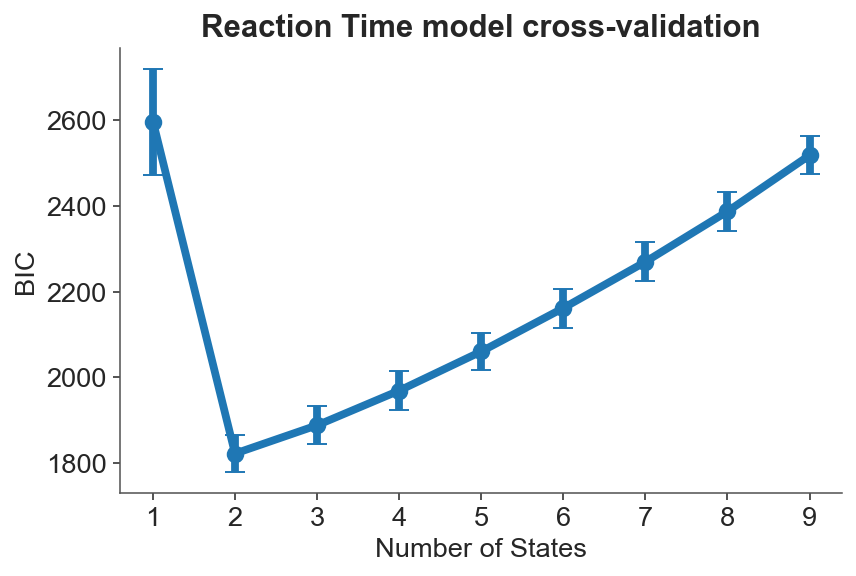

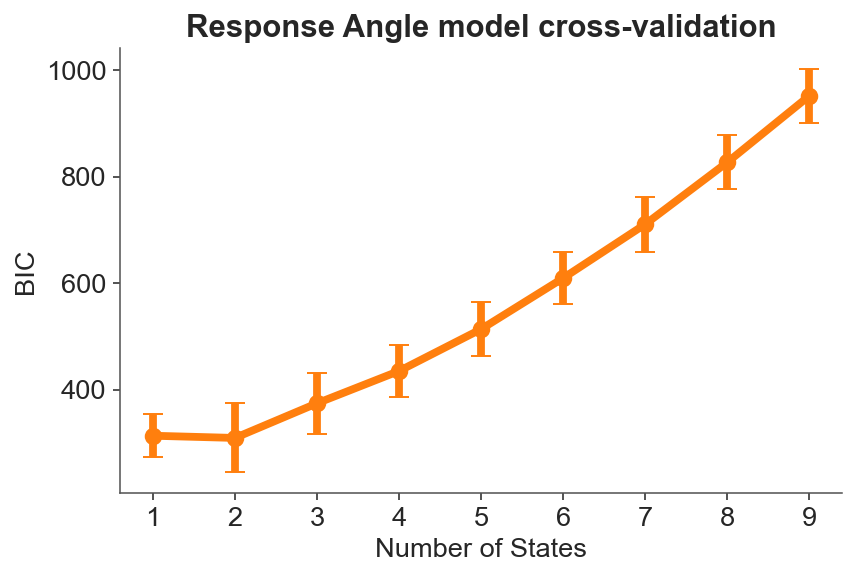

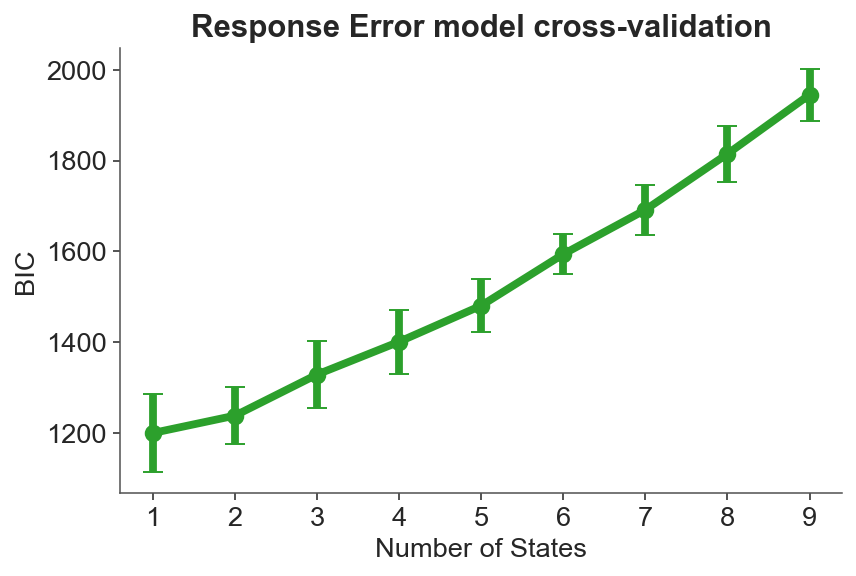

In [11]:
def join_crosvals(crossval_results, ost_crossval):
    full_crossval = crossval_results.copy()
    for idx in range(12):
        full_crossval[idx][1] = ost_crossval[idx][1].flatten()
        
    return full_crossval

rt_full_crossval = join_crosvals(rt_sub_crossval, rt_one_state)
ra_full_crossval = join_crosvals(ra_sub_crossval, ra_one_state)
re_full_crossval = join_crosvals(re_sub_crossval, re_one_state)

cvs = (rt_full_crossval, ra_full_crossval, re_full_crossval)
for i in range(0,3):
    all_cv, all_aic, all_bic = get_aic_bic(cvs[i], input_dims[i], emission_dims[i])
    
    plt.figure(figsize=(6, 4))
    x = np.arange(1, 10)
    y = all_bic.mean(axis=0)
    yerr = all_bic.std(axis=0)

    plt.errorbar(
        x, y,
        yerr=yerr,
        fmt='-o',                  # line + circle markers
        color=colors[i],
        alpha=1,
        label="bic",
        linewidth=4,
        markersize=8,
        capsize=5                  # length of the little “T” on each error bar end
    )
    
    plt.ylabel("BIC")
    plt.xticks(np.arange(1, 10))
    plt.xlabel("Number of States")
    plt.title(f"{titles[i]} model cross-validation")
    plt.show()
    
    # plot_mloocv(all_cv, all_aic, all_bic, titles[i])
    
    

## Params of rt model

In [110]:
rt_column_names = ['bias', 'resp_err', 'att', 'coh', 'exp', 'err*att', 'err*coh', 'err*exp']

In [124]:
all_state_0 = np.array([ rt_sub_params[i][2].emissions.w1[0] for i in range(12) ])
all_state_1 = np.array([ rt_sub_params[i][2].emissions.w1[1] for i in range(12) ])

all_concen_0 = np.array([ rt_sub_params[i][2].emissions.w2[0] for i in range(12) ])
all_concen_1 = np.array([ rt_sub_params[i][2].emissions.w2[1] for i in range(12) ])

trans_ra = [ rt_sub_params[i][2].transitions.transition_matrix for i in range(12) ]
trans_ra = np.array(trans_ra)

slow_transitions = []
fast_transitions = []

slow_params = []
fast_params = []

slow_concentration = []
fast_concentration = []

for i in range(12):
    # if the 1th (stimulus) absolute value is larger than then keep in engaged
    if np.exp(all_state_1[i][0]) > np.exp(all_state_0[i][0] ):
        slow_params.append(all_state_1[i])
        fast_params.append(all_state_0[i])
        
        slow_concentration.append(all_concen_1[i])
        fast_concentration.append(all_concen_0[i])
        
        slow_transitions.append(trans_ra[i][1])
        fast_transitions.append(trans_ra[i][0])
    else:
        slow_params.append(all_state_0[i])
        fast_params.append(all_state_1[i])
        
        slow_concentration.append(all_concen_0[i])
        fast_concentration.append(all_concen_1[i])
        
        slow_transitions.append(trans_ra[i][0])
        fast_transitions.append(trans_ra[i][1])
    

<Axes: ylabel='Transition Probability'>

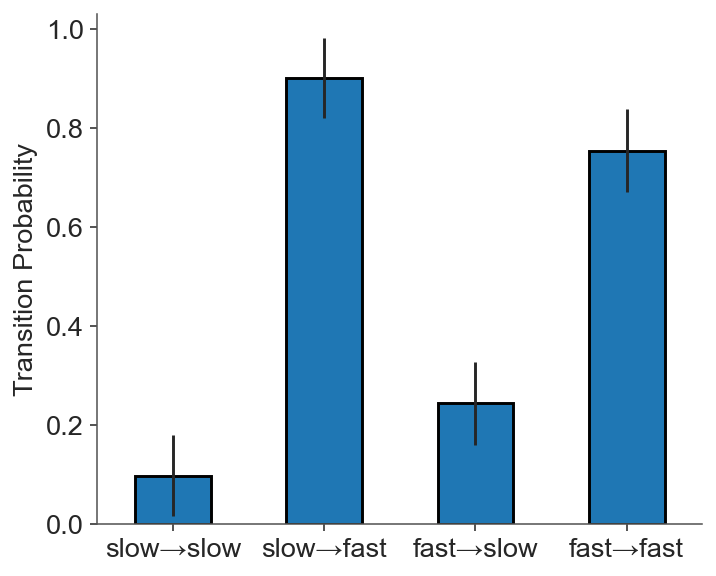

In [133]:
ra_trans_df = pd.DataFrame(np.concatenate([slow_transitions, fast_transitions], axis=-1), columns=["slow→slow", "slow→fast", "fast→slow", "fast→fast"])
# Now plotting the att, coh and exp during engaged and disengaged states
ra_trans_df.mean().plot.bar(
    figsize=(5, 4), 
    yerr=ra_trans_df.sem(),
    # title="Transition Probabilities",
    ylabel="Transition Probability",
    # xlabel="Covariates",
    color=colors[0],
    edgecolor='black',
    linewidth=1.5,
    rot=0,
    width=0.5,
)

In [135]:
slow_df = pd.DataFrame(slow_params, columns=rt_column_names).apply(np.exp)
slow_df

,bias,resp_err,att,coh,exp,err*att,err*coh,err*exp
0,317.528656,0.945321,1.034701,0.960051,1.097946,0.882027,0.975860,1.024163
1,1101.113770,0.986485,0.963561,0.924122,1.040979,1.049645,0.973749,1.025293
2,772.864746,1.005379,0.937335,1.035869,0.984525,0.969046,0.904237,1.010079
3,832.731995,1.017770,0.922302,1.026289,1.067887,1.003784,0.920968,0.937815
4,1430.926636,1.020323,0.954524,0.946496,0.996291,0.955603,0.946432,0.997515
5,1091.806396,1.006961,0.966007,0.913604,0.990285,0.932050,0.972863,1.019866
6,643.143738,0.975841,0.919783,1.052205,0.965016,0.957592,0.955574,1.054590
7,1025.341309,1.037103,0.924254,0.938639,1.020837,0.978530,0.979827,1.011834
8,1096.097778,1.032713,0.954246,0.869895,0.977032,1.029271,1.002803,1.017148
9,1158.666016,1.034244,0.980732,0.921706,1.005021,0.970739,1.035466,0.990660


In [134]:
fast_df = pd.DataFrame(fast_params, columns=rt_column_names).apply(np.exp)
fast_df

,bias,resp_err,att,coh,exp,err*att,err*coh,err*exp
0,1.065733,1.053134,1.083917,1.045934,1.082611,1.071855,1.017316,1.064952
1,1.150800,1.143809,1.147210,1.149054,1.147699,1.138449,1.139423,1.139623
2,0.010000,0.999989,0.999992,0.999993,0.999989,1.000005,1.000004,1.000007
3,0.014218,0.754509,0.883481,0.885997,0.813575,1.123631,1.101229,1.173267
4,0.577718,0.696634,0.430189,0.451139,0.071675,0.941494,0.539700,0.770013
5,1.150196,1.143575,1.146546,1.148098,1.147297,1.138044,1.138914,1.138501
6,0.440718,2.267959,0.089605,0.413149,0.493384,0.301560,0.801613,1.279688
7,0.300271,0.445431,0.529617,0.749860,0.241094,1.450039,1.094889,0.459311
8,0.508629,0.282922,0.811034,0.625990,0.497846,0.492890,1.638064,0.564640
9,0.013222,0.819733,0.904962,0.867080,0.790917,1.083622,1.119847,1.179700


<Axes: title={'center': 'Slow'}, ylabel='Miliseconds'>

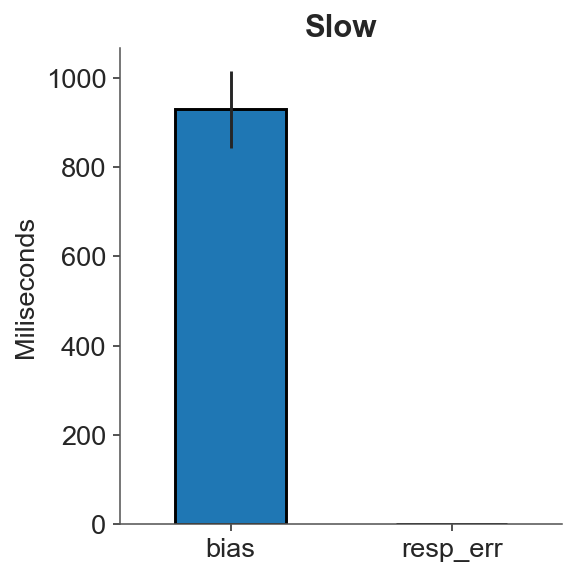

In [138]:
# lets barplot only thses: bias	stim	p_stim	p_resp columns
cols = ["bias", "resp_err"]
slow_df[cols].mean().plot.bar(
    figsize=(4, 4), 
    yerr=slow_df[cols].sem(),
    title="Slow",
    ylabel="Miliseconds",
    # xlabel="Covariates",
    color=colors[0],
    edgecolor='black',
    linewidth=1.5,
    rot=0,
    # ylim=(-0.3, 1.8),
)

<Axes: title={'center': 'Slow'}, ylabel='Miliseconds'>

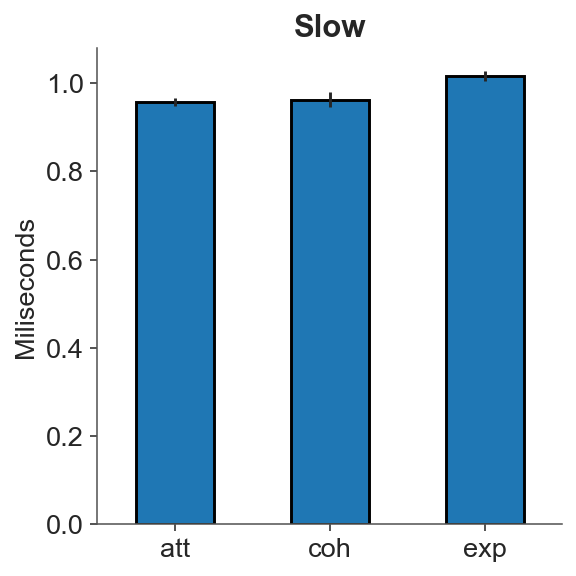

In [142]:
# Now plotting the att, coh and exp during engaged and disengaged states
slow_df[["att", "coh", "exp"]].mean().plot.bar(
    figsize=(4, 4), 
    yerr=slow_df[["att", "coh", "exp"]].sem(),
    title="Slow",
    ylabel="Miliseconds",
    # xlabel="Covariates",
    color=colors[0],
    edgecolor='black',
    linewidth=1.5,
    rot=0,
)

<Axes: title={'center': 'Fast'}, ylabel='Miliseconds'>

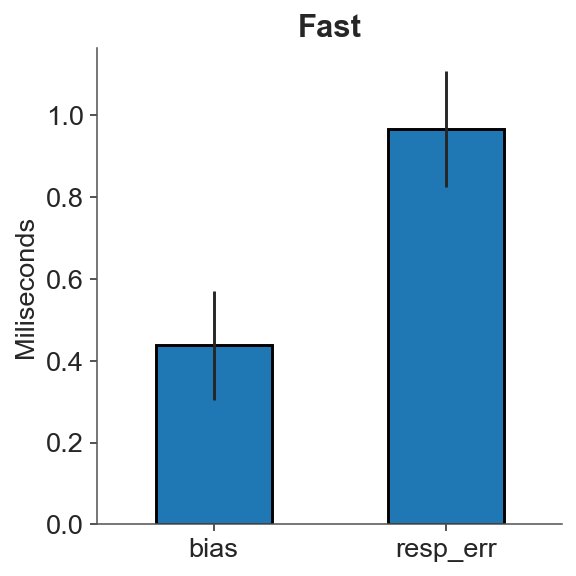

In [143]:
# lets barplot only thses: bias	stim	p_stim	p_resp columns
cols = ["bias", "resp_err"]
fast_df[cols].mean().plot.bar(
    figsize=(4, 4), 
    yerr=fast_df[cols].sem(),
    title="Fast",
    ylabel="Miliseconds",
    # xlabel="Covariates",
    color=colors[0],
    edgecolor='black',
    linewidth=1.5,
    rot=0,
    # ylim=(-0.3, 1.8),
)

<Axes: title={'center': 'Fast'}, ylabel='Miliseconds'>

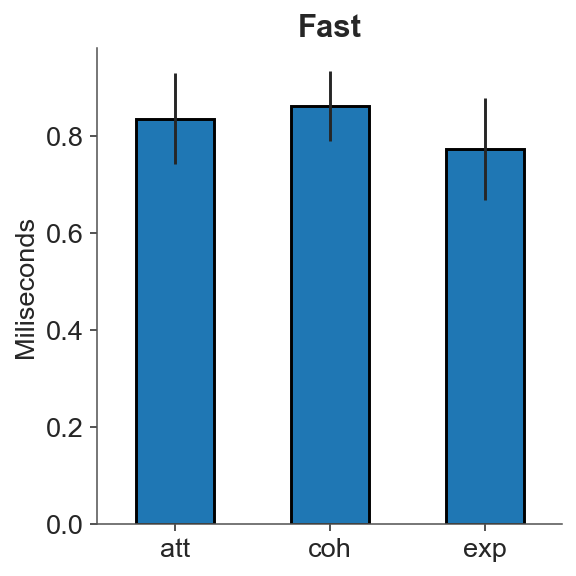

In [145]:
# Now plotting the att, coh and exp during engaged and disengaged states
fast_df[["att", "coh", "exp"]].mean().plot.bar(
    figsize=(4, 4), 
    yerr=fast_df[["att", "coh", "exp"]].sem(),
    title="Fast",
    ylabel="Miliseconds",
    # xlabel="Covariates",
    color=colors[0],
    edgecolor='black',
    linewidth=1.5,
    rot=0,
)

## Params of RA model

In [111]:
# bar plot with 2 values

In [112]:
for i in range(12):
    print(ra_sub_params[i][2].emissions.w1[0][:2], ra_sub_params[i][2].emissions.w1[1][:2])


[0.8875961  0.01650075] [2.2367067  0.02055988]
[-0.01106553  0.95981497] [ 2.9482722 -0.8648026]
[1.3641477  0.22921975] [1.0865796  0.10707328]
[0.6847293  0.02718685] [1.8740964  0.09169796]
[ 2.0913358 -0.2775797] [0.16119409 0.918032  ]
[ 2.5324955  -0.70517707] [0.20664644 0.8172371 ]
[2.080022   0.02006193] [0.6665611  0.00265895]
[0.06070232 0.940047  ] [ 1.6322227  -0.07256669]
[ 1.5036594  -0.11939874] [0.05209748 0.87056726]
[0.07561185 0.8890019 ] [ 1.4994645  -0.26635045]
[ 1.752614   -0.02180051] [ 0.8961354  -0.02522603]
[0.8367468  0.28784105] [2.4076443  0.03492928]


In [113]:
# for i in range(12):
#     print(ra_sub_params[i][2].emissions.w1[0].tolist())
#     print(ra_sub_params[i][2].emissions.w1[1])
    
#     print("sub--")

In [114]:
# RA features: [1, stim, p_stim, p_resp, Att, Coh, Exp]
column_names = [ "bias", "stim", "p_stim", "p_resp", "Att", "Coh", "Exp"]

In [115]:
all_state_0 = np.array([ ra_sub_params[i][2].emissions.w1[0] for i in range(12) ])
all_state_1 = np.array([ ra_sub_params[i][2].emissions.w1[1] for i in range(12) ])

all_concen_0 = np.array([ ra_sub_params[i][2].emissions.w2[0] for i in range(12) ])
all_concen_1 = np.array([ ra_sub_params[i][2].emissions.w2[1] for i in range(12) ])

trans_ra = [ ra_sub_params[i][2].transitions.transition_matrix for i in range(12) ]
trans_ra = np.array(trans_ra)

engaged_transitions = []
disengaged_transitions = []

engaged_params = []
disengaged_params = []

engaged_concentration = []
disengaged_concentration = []

for i in range(12):
    # if the 1th (stimulus) absolute value is larger than then keep in engaged
    if np.abs(all_state_1[i][1]) > np.abs(all_state_0[i][1]):
        engaged_params.append(all_state_1[i])
        disengaged_params.append(all_state_0[i])
        
        engaged_concentration.append(all_concen_1[i])
        disengaged_concentration.append(all_concen_0[i])
        
        engaged_transitions.append(trans_ra[i][1])
        disengaged_transitions.append(trans_ra[i][0])
    else:
        engaged_params.append(all_state_0[i])
        disengaged_params.append(all_state_1[i])
        
        engaged_concentration.append(all_concen_0[i])
        disengaged_concentration.append(all_concen_1[i])
        
        engaged_transitions.append(trans_ra[i][0])
        disengaged_transitions.append(trans_ra[i][1])
    

In [116]:
engaged_transitions

[array([0.7376056 , 0.26239452], dtype=float32),
 array([0.7566176 , 0.24338233], dtype=float32),
 array([0.68148553, 0.31851447], dtype=float32),
 array([0.49058068, 0.5094193 ], dtype=float32),
 array([0.5302787 , 0.46972135], dtype=float32),
 array([0.25598907, 0.74401104], dtype=float32),
 array([0.50026196, 0.499738  ], dtype=float32),
 array([0.38735652, 0.61264354], dtype=float32),
 array([0.34735996, 0.6526401 ], dtype=float32),
 array([0.6422286 , 0.35777143], dtype=float32),
 array([0.5199376 , 0.48006245], dtype=float32),
 array([0.623338  , 0.37666205], dtype=float32)]

In [117]:
disengaged_transitions

[array([0.48827255, 0.51172745], dtype=float32),
 array([0.756174 , 0.2438259], dtype=float32),
 array([0.500649  , 0.49935102], dtype=float32),
 array([0.3619375, 0.6380625], dtype=float32),
 array([0.48398143, 0.51601857], dtype=float32),
 array([0.26928458, 0.7307154 ], dtype=float32),
 array([0.6748638 , 0.32513627], dtype=float32),
 array([0.34651166, 0.6534884 ], dtype=float32),
 array([0.3551609, 0.6448391], dtype=float32),
 array([0.63373613, 0.36626384], dtype=float32),
 array([0.44881663, 0.5511834 ], dtype=float32),
 array([0.8046936 , 0.19530648], dtype=float32)]

In [118]:
np.array(engaged_concentration).flatten()

array([23.086369 , 21.588865 ,  3.0137184,  6.5950885, 21.353355 ,
       20.654621 ,  7.1628947, 21.041235 , 21.53544  , 21.758959 ,
        3.9544384,  3.416247 ], dtype=float32)

In [119]:
np.array(disengaged_concentration).flatten()

array([ 8.700231 , 12.3151865,  2.317058 ,  9.755032 ,  3.323849 ,
        7.638088 , 21.984259 ,  2.3455634,  4.9306335,  2.684652 ,
        2.5948458, 21.985983 ], dtype=float32)

(-0.5, 1.5)

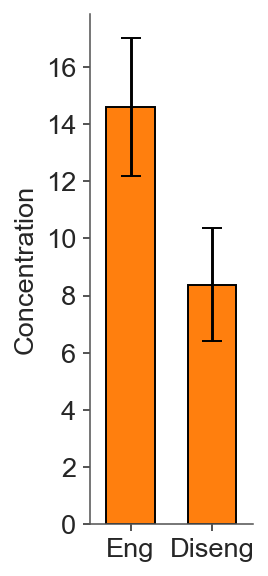

In [121]:
# make 2 bars with these values and error bars
# first bar is engaged, second is disengaged

plt.figure(figsize=(1.8, 4))

bar_y = [np.array(engaged_concentration).flatten().mean(), np.array(disengaged_concentration).flatten().mean()]
# bar_yerr = [np.array(engaged_concentration).flatten().std(), np.array(disengaged_concentration).flatten().std()]
bar_yerr_sem = [np.array(engaged_concentration).flatten().std() / np.sqrt(12),
                np.array(disengaged_concentration).flatten().std() / np.sqrt(12)]
plt.bar(
    ["Eng", "Diseng"],
    bar_y,
    yerr=bar_yerr_sem,
    color=colors[1],
    edgecolor='black',
    alpha=1,
    capsize=5,
    width=0.6,
)
plt.ylabel("Concentration")
plt.xlim(-0.5, 1.5)


<Axes: ylabel='Transition Probability'>

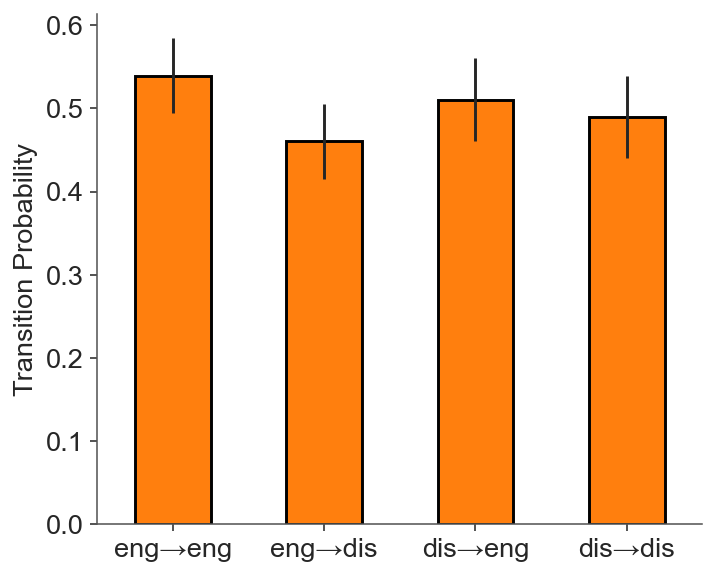

In [123]:
ra_trans_df = pd.DataFrame(np.concatenate([engaged_transitions, disengaged_transitions], axis=-1), columns=["eng→eng", "eng→dis", "dis→eng", "dis→dis"])
# Now plotting the att, coh and exp during engaged and disengaged states
ra_trans_df.mean().plot.bar(
    figsize=(5, 4), 
    yerr=ra_trans_df.sem(),
    # title="Transition Probabilities",
    ylabel="Transition Probability",
    # xlabel="Covariates",
    color=colors[1],
    edgecolor='black',
    linewidth=1.5,
    rot=0,
    width=0.5,
)

In [33]:
engaged_df = pd.DataFrame(engaged_params, columns=column_names) * (180 / np.pi)
engaged_df

,bias,stim,p_stim,p_resp,Att,Coh,Exp
0,128.153854,1.177995,1.068539,0.994866,-0.355011,0.185042,0.797695
1,-0.634008,54.993347,-0.300588,0.779178,-0.673655,0.746605,-0.213984
2,78.159904,13.133325,6.652716,-2.822817,7.170867,-4.762537,-0.271084
3,107.377815,5.253906,1.479196,3.151477,-1.723339,-3.299370,0.173172
4,9.235741,52.599358,-1.250961,0.305946,0.652134,-0.469032,-2.959436
5,11.839969,46.824238,-0.061650,0.260921,-0.151606,0.933080,2.268773
6,119.176491,1.149464,-1.981500,-2.436606,4.930823,-1.140925,-0.770340
7,3.477987,53.860729,0.294480,1.079360,-0.811559,1.166419,1.920470
8,2.984966,49.879829,-2.727775,5.931097,0.666251,-0.293517,-0.002653
9,4.332240,50.936058,0.577065,0.290672,-0.733532,0.296629,0.245925


In [34]:
disengaged_df = pd.DataFrame(disengaged_params, columns=column_names) * (180 / np.pi)
disengaged_df

,bias,stim,p_stim,p_resp,Att,Coh,Exp
0,50.855511,0.945423,0.141810,-3.420606,2.052727,-0.420557,0.180262
1,168.923553,-49.549541,-2.305541,3.765736,1.425127,-0.026577,-2.227201
2,62.256424,6.134847,-7.114153,8.086992,-16.580179,6.792168,-3.927288
3,39.232098,1.557692,-0.525882,0.594249,-0.247862,-0.942272,-1.343672
4,119.824715,-15.904145,-1.491519,-6.893465,-0.497105,-4.391643,3.154938
5,145.101303,-40.403671,0.211222,0.946717,-2.038546,-2.329308,0.925491
6,38.191139,0.152347,-0.507747,0.304259,-2.040319,0.797853,-1.309457
7,93.519470,-4.157765,0.639425,-4.031464,-1.180654,2.148310,-0.333741
8,86.153336,-6.841043,0.351441,4.567929,0.681413,0.291349,-0.565401
9,85.912987,-15.260756,-0.748713,7.302848,-2.435167,-2.613252,4.539569


<Axes: title={'center': 'Engaged'}, ylabel='Degrees'>

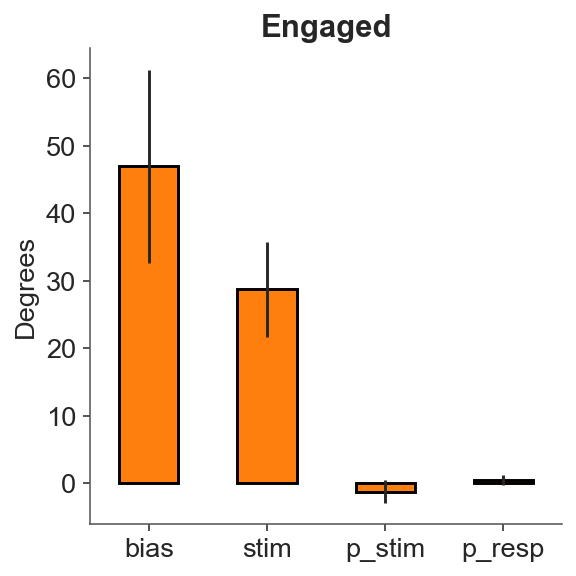

In [35]:
# lets barplot only thses: bias	stim	p_stim	p_resp columns
cols = ["bias", "stim", "p_stim", "p_resp"]
errors = engaged_df[cols].sem()
engaged_df[cols].mean().plot.bar(
    figsize=(4, 4), 
    yerr=errors,
    title="Engaged",
    ylabel="Degrees",
    # xlabel="Covariates",
    color=colors[1],
    edgecolor='black',
    linewidth=1.5,
    rot=0,
    # ylim=(-0.3, 1.8),
)

<Axes: title={'center': 'Disengaged'}, ylabel='Degrees'>

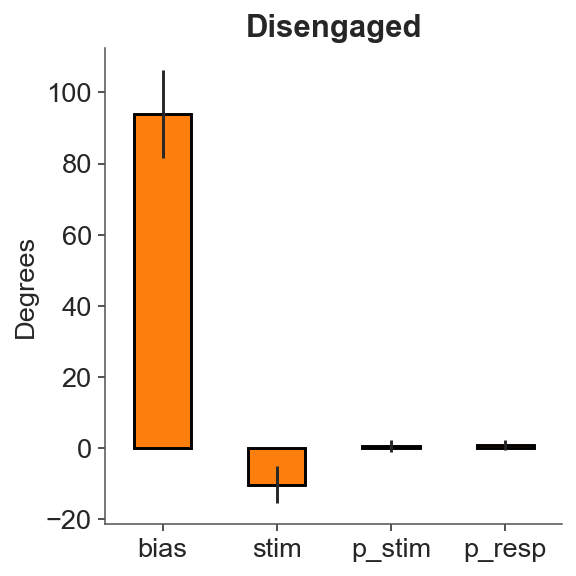

In [36]:
# lets barplot only thses: bias	stim	p_stim	p_resp columns
cols = ["bias", "stim", "p_stim", "p_resp"]
errors = disengaged_df[cols].sem()
disengaged_df[cols].mean().plot.bar(
    figsize=(4, 4), 
    yerr=errors,
    title="Disengaged",
    ylabel="Degrees",
    # xlabel="Covariates",
    color=colors[1],
    edgecolor='black',
    linewidth=1.5,
    rot=0,
    # ylim=(-0.3, 1.8),
)

<Axes: title={'center': 'Engaged'}, ylabel='Degrees'>

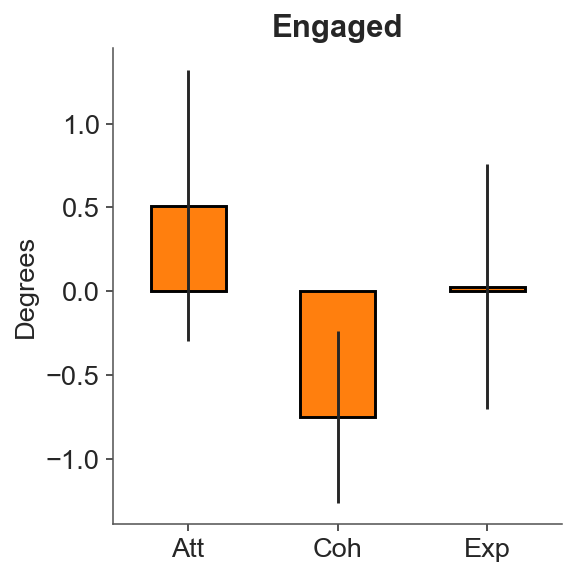

In [37]:
# Now plotting the att, coh and exp during engaged and disengaged states
engaged_df[["Att", "Coh", "Exp"]].mean().plot.bar(
    figsize=(4, 4), 
    yerr=engaged_df[["Att", "Coh", "Exp"]].sem(),
    title="Engaged",
    ylabel="Degrees",
    # xlabel="Covariates",
    color=colors[1],
    edgecolor='black',
    linewidth=1.5,
    rot=0,
)

<Axes: title={'center': 'Disengaged'}, ylabel='Degrees'>

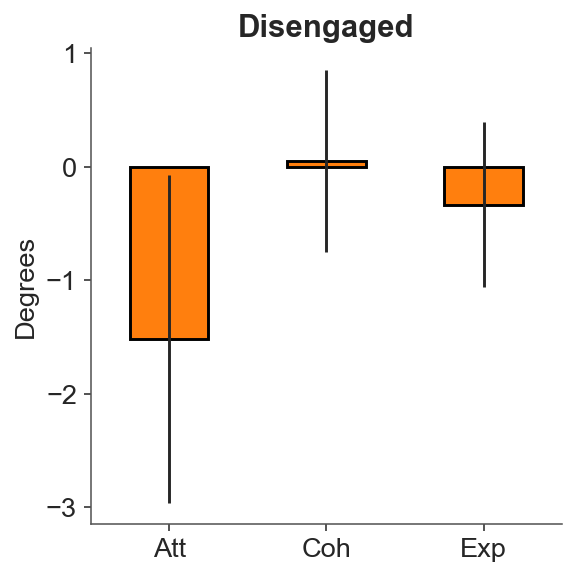

In [38]:
disengaged_df[["Att", "Coh", "Exp"]].mean().plot.bar(
    figsize=(4, 4), 
    yerr=disengaged_df[["Att", "Coh", "Exp"]].sem(),
    title="Disengaged",
    ylabel="Degrees",
    # xlabel="Covariates",
    color=colors[1],
    edgecolor='black',
    linewidth=1.5,
    rot=0,
)

## Now RE model

In [39]:
re_sub_params

{0: {1: {'alpha_re': Array(0.49945232, dtype=float32),
   'weights_re': Array([ 1.5745134 ,  0.00562681,  1.1377202 ,  1.1216825 ,  1.1570096 ,
          -0.00272838, -0.00274649, -0.00288214], dtype=float32)}},
 1: {1: {'alpha_re': Array(0.67294455, dtype=float32),
   'weights_re': Array([ 7.7255273e-01,  2.4454822e-03,  1.0995541e+00,  1.0133405e+00,
           5.9196329e-01, -1.0246587e-03, -1.4659823e-03, -4.4595177e-04],      dtype=float32)}},
 2: {1: {'alpha_re': Array(0.65046585, dtype=float32),
   'weights_re': Array([ 1.6376033e+00,  2.6751976e-03,  1.2240841e+00,  1.1367038e+00,
           1.1952950e+00, -1.4061101e-03, -1.6448656e-03, -1.4320820e-03],      dtype=float32)}},
 3: {1: {'alpha_re': Array(0.78978664, dtype=float32),
   'weights_re': Array([ 1.5376892e+00,  2.5571284e-03,  1.2309853e+00,  1.2119583e+00,
           1.1578566e+00, -1.2684222e-03, -1.4603401e-03, -1.2924441e-03],      dtype=float32)}},
 4: {1: {'alpha_re': Array(0.71354145, dtype=float32),
   'weight

In [64]:
x_re.max()

Array(2283.3333, dtype=float32)

In [68]:
x_re.mean()

Array(285.41562, dtype=float32)

In [61]:
re_params = np.array([ re_sub_params[i][1]["weights_re"] for i in range(12) ]).reshape(12, 8)
re_columns = ["bias", "RT", "Att", "Coh", "Exp", "RT*Att", "RT*Coh", "RT*Exp"]

re_df = pd.DataFrame(re_params, columns=re_columns)

In [62]:
re_df

,bias,RT,Att,Coh,Exp,RT*Att,RT*Coh,RT*Exp
0,1.574513,0.005627,1.137720,1.121683,1.157010,-0.002728,-0.002746,-0.002882
1,0.772553,0.002445,1.099554,1.013340,0.591963,-0.001025,-0.001466,-0.000446
2,1.637603,0.002675,1.224084,1.136704,1.195295,-0.001406,-0.001645,-0.001432
3,1.537689,0.002557,1.230985,1.211958,1.157857,-0.001268,-0.001460,-0.001292
4,1.229437,0.001798,1.483765,1.173434,0.923606,-0.001074,-0.001146,-0.000602
5,0.979828,0.002560,1.540930,1.094659,0.753755,-0.001542,-0.001518,-0.000782
6,1.478190,0.003452,1.354897,1.172433,1.062456,-0.001914,-0.001787,-0.001471
7,1.174091,0.002711,1.376948,1.143976,0.932368,-0.001443,-0.001442,-0.000949
8,0.960468,0.002479,0.933287,0.862304,0.712605,-0.001100,-0.001390,-0.000775
9,1.500547,0.001901,1.166912,0.910366,0.984743,-0.001056,-0.001135,-0.000956


In [58]:
np.exp(4)

54.598150033144236